In [140]:
import pandas as pd 
import numpy as np
from scipy import stats 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder
from sklearn.preprocessing import StandardScaler,RobustScaler,OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import PowerTransformer
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import warnings

warnings.filterwarnings('ignore')
#sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#statistical libraries 
from scipy import stats
from scipy.stats import zscore, skew 

import joblib

# set style for better visualizations 
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("libraries imported successfully!")


libraries imported successfully!


In [141]:
loan_df = pd.read_csv('home_loan_train.csv')

df = loan_df.copy()


In [142]:
df.dropna(subset=['Credit_History'],inplace=True)

In [143]:
df.isnull().sum()

Loan_ID               0
Gender               12
Married               3
Dependents           15
Education             0
Self_Employed        26
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           21
Loan_Amount_Term     14
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

In [ ]:
numerical =df.select_dtypes(include=['float64','int64']).columns

numerical=numerical.drop('Credit_History')

categorical = df.select_dtypes(include='object').columns
categorical = list(categorical)
categorical.append('Credit_History')

In [145]:
for col in categorical:
 x=df[col].mode()[0]
 df[col]=df[col].fillna(x)

for col in numerical:
  df[col]=df[col].fillna(df[col].median())

In [146]:
df.duplicated().sum()

np.int64(0)

In [147]:
df['Loan_Amount_Term'].skew()

np.float64(-2.3139085450009556)

numerical
categorical
skewed_vars


In [ ]:
skewed_vars = ['LoanAmount', 'ApplicantIncome', 'CoapplicantIncome','Loan_Amount_Term']

for var in skewed_vars:
    if var in df.columns:
        if df[var].skew() > 0:
            # Check if variable has zero or negative values
            min_val = df[var].min()
            if min_val <= 0:
                # Use log1p for variables with zeros
                df[f'{var}_log'] = np.log1p(df[var])
                print(f"✓ {var}: Applied log1p transformation (had {min_val:.3f} minimum value)")
            else:
                # Use log for positive values only
                df[f'{var}_log'] = np.log(df[var])
                print(f"✓ {var}: Applied log transformation")
        else:
            pt = PowerTransformer(method='yeo-johnson')
            df[f'{var}_log'] = pt.fit_transform(df[var].values.reshape(-1,1))
            print(f"✓ {var}: Applied yeo-johnsons transformation")
    # Check skewness before and after
    original_skew = skew(df[var])
    transformed_skew = skew(df[f'{var}_log'])
    print(f"  Original skewness: {original_skew:.3f} → Transformed skewness: {transformed_skew:.3f}")

print(f"\nDataset shape after log transformation: {df.shape}")
print("New log-transformed columns:", [col for col in df.columns if '_log' in col])


consider other transformation methods on subsequent evaluations because its over flipping the data i am now having negative skewness 

In [150]:
df['Dependents']=df['Dependents'].replace("3+",3)

In [151]:
df['Dependents'].value_counts()

Dependents
0    331
2     95
1     90
3     48
Name: count, dtype: int64

Handling outliers 

In [152]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'LoanAmount_log', 'ApplicantIncome_log', 'CoapplicantIncome_log',
       'Loan_Amount_Term_log'],
      dtype='object')

In [153]:
# univariate analysis of the 
def univariate_numerical_eda(df, column):
    """
    Performs univariate EDA on a single numerical column.
    Displays summary statistics, skewness, kurtosis, histogram, KDE, and boxplot.
    """
    print(f" Feature: {column}")
    print("="*40)
    print(df[column].describe().to_frame())
    print(f"\nSkewness: {df[column].skew():.3f}")
    print(f"Kurtosis: {df[column].kurt():.3f}")

    plt.figure(figsize=(12,4))

    # Histogram + KDE
    plt.subplot(1,2,1)
    sns.histplot(df[column], kde=True, bins=30, color='teal')
    plt.title(f'\n Distribution of {column}', fontsize=13)
    plt.xlabel(column)
    plt.ylabel('Frequency')

    # Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(x=df[column], color='teal')
    plt.title(f'\n Boxplot of {column}', fontsize=13)

    plt.tight_layout()
    plt.show()

    # Optional note on transformation
    if abs(df[column].skew()) > 1:
        print(f"\n {column} is highly skewed. Consider log or Box-Cox transformation.")
    elif abs(df[column].skew()) > 0.5:
        print(f"{column} is moderately skewed.")
    else:
        print(f"{column} is fairly symmetric.")


In [ ]:
numer= [column for column in df.columns if  any( keyword in column.lower() for keyword in ['log'])]
print(numer)
for column in numer:
    univariate_numerical_eda(df,column)

we still have outliers so i move forward if handling them using Robust scaler

In [156]:
scaler = StandardScaler()
df[numer]= scaler.fit_transform(df[numer])

In [157]:
# for column in numer:
#     univariate_numerical_eda(df,column)

In [ ]:
df['Loan_to_Income_Ratio'] = (df['LoanAmount_log']) / (df['ApplicantIncome_log'] + df['CoapplicantIncome_log'])

df['Total_Income']= df['ApplicantIncome']  +	df['CoapplicantIncome']

# Feature 1: People per Dollar (Inverse of Income per person)
# Lower value indicates more people sharing the income
df['amountspent_Per_Person'] = df['Total_Income'] / (df['Dependents'].astype(int) + 1) # Add 1 for the applicant

# Combine married status and dependents count into a single indicator
df['Household_Load'] = df['Dependents'].astype(int) + df['Married'].map({'No': 1, 'Yes': 2})



Ecncoding 

In [161]:
df['Property_Area'].nunique()

3

In [162]:
categorical.remove('Property_Area')

In [163]:
y= df['Loan_Status']
Y= pd.Series(y, name='Loan_Status')

df.drop('Loan_Status',axis=1,inplace=True)
df.drop('Loan_ID',axis=1,inplace=True)

In [ ]:
lenc= LabelEncoder()
label = OneHotEncoder(sparse_output=False, drop="first")
labelencoded=[]
OneHotEncoded=[]
OrdinalEncoded=['Property_Area']
for cat in categorical:
    if cat in df.columns:
        print(cat)
        print(df[cat].dtype)
        print(df[cat].nunique())
        if df[cat].nunique() ==2:
            df[cat]= lenc.fit_transform(df['Gender'])
            labelencoded.append(cat)
        elif df[cat].nunique()>2:
            try:
                df[cat]=df[cat].astype(int)

            except Exception as e: 
                df[cat]=df[cat].astype(str)
            encoded=label.fit_transform(df[[cat]])
            OneHotEncoded.append(cat)
            print(f'{cat} encoded')
ordlabel=OrdinalEncoder()

df['Property_Area']=ordlabel.fit_transform(df[['Property_Area']])


Gender
object
2
Married
object
2
Dependents
object
4
Dependents encoded
Education
object
2
Self_Employed
object
2
Credit_History
float64
2


In [165]:

Y = Y.map({'Y': 1, 'N': 0})
corrank=df.corrwith((Y.astype(int)))
corrank

Gender                    0.039194
Married                   0.039194
Dependents                0.024601
Education                 0.039194
Self_Employed             0.039194
ApplicantIncome          -0.004530
CoapplicantIncome        -0.033784
LoanAmount               -0.028275
Loan_Amount_Term         -0.019790
Credit_History            0.039194
Property_Area             0.026222
LoanAmount_log           -0.028700
ApplicantIncome_log       0.010486
CoapplicantIncome_log     0.066850
Loan_Amount_Term_log     -0.057707
Loan_to_Income_Ratio     -0.031003
Total_Income             -0.017367
amountspent_Per_Person   -0.025455
Household_Load            0.052347
dtype: float64

In [166]:

for num in df.columns:
    if num in numerical:
        df=df.drop(num,axis=1)


In [167]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,Credit_History,Property_Area,LoanAmount_log,ApplicantIncome_log,CoapplicantIncome_log,Loan_Amount_Term_log,Loan_to_Income_Ratio,Total_Income,amountspent_Per_Person,Household_Load
0,1,1,0,1,1,1,2.0,-0.012002,0.502952,-1.095472,0.17134,0.020256,5849.0,5849.0,1
1,1,1,1,1,1,1,0.0,0.003856,0.124445,0.797989,0.17134,0.004181,6091.0,3045.5,3
2,1,1,0,1,1,1,2.0,-1.335453,-0.533110,-1.095472,0.17134,0.820010,3000.0,3000.0,2
3,1,1,0,1,1,1,2.0,-0.126639,-0.765352,0.913573,0.17134,-0.854395,4941.0,4941.0,2
4,1,1,0,1,1,1,2.0,0.199442,0.542505,-1.095472,0.17134,-0.360676,6000.0,6000.0,1


Splitting data

now lets split

=== FEATURE IMPORTANCE ANALYSIS ===
Top 10 features by correlation with quality:
 1. CoapplicantIncome_log: 0.067
 2. Loan_Amount_Term_log: 0.058
 3. Household_Load: 0.052
 4. Credit_History: 0.039
 5. Gender: 0.039
 6. Married: 0.039
 7. Education: 0.039
 8. Self_Employed: 0.039
 9. Loan_to_Income_Ratio: 0.031
10. LoanAmount_log: 0.029

Engineered features in top 10: ['LoanAmount_log', 'CoapplicantIncome_log', 'Loan_Amount_Term_log', 'Loan_to_Income_Ratio', 'Household_Load']


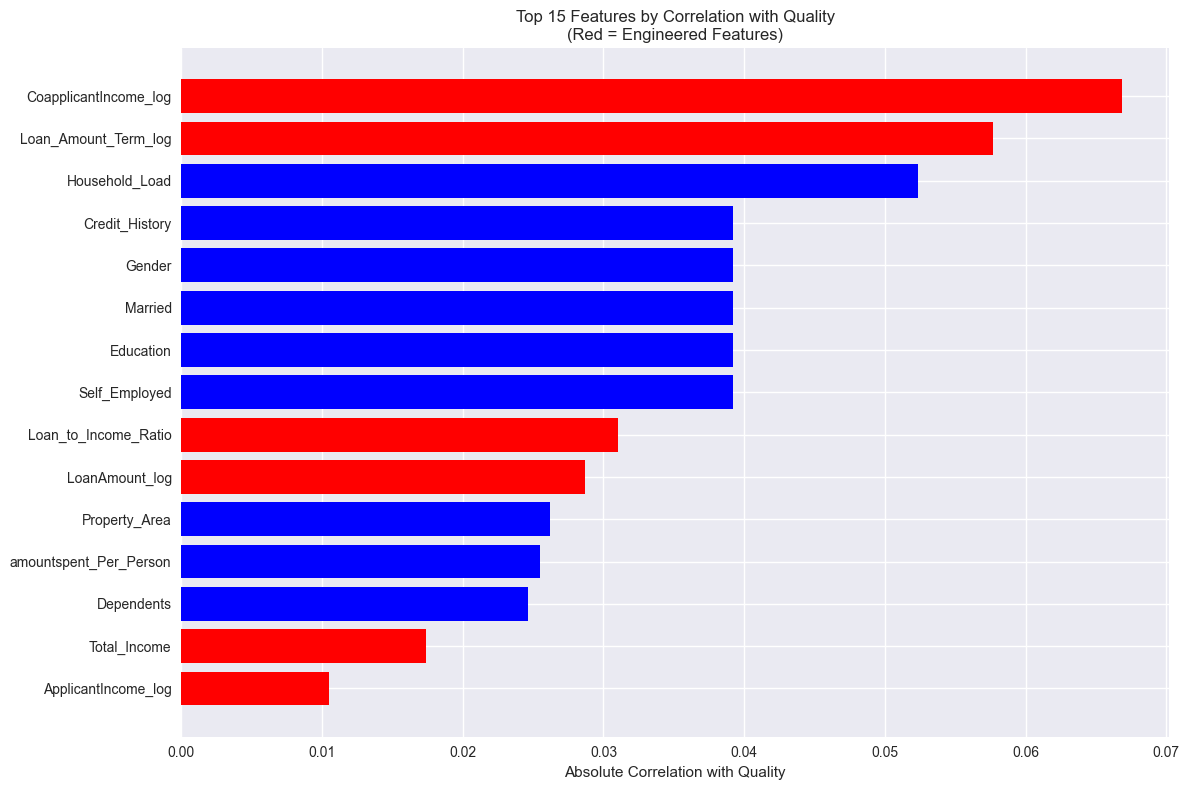


✓ Feature importance analysis completed
✓ 5 engineered features in top 10


In [168]:
# Feature importance analysis to validate EDA-based engineering
print("=== FEATURE IMPORTANCE ANALYSIS ===")

# Calculate correlation with target for all features
feature_correlations = df.corrwith(Y).abs().sort_values(ascending=False)


print("Top 10 features by correlation with quality:")
for i, (feature, corr) in enumerate(feature_correlations.head(10).items(), 1):
    print(f"{i:2d}. {feature}: {corr:.3f}")

# Check if engineered features are among top features
engineered_features = [col for col in df.columns if any(keyword in col.lower() for keyword in ['ratio','load','spent' 'total', 'log'])]
print(f"\nEngineered features in top 10: {[f for f in engineered_features if f in feature_correlations.head(10).index]}")

# Visualize feature importance
plt.figure(figsize=(12, 8))
top_features = feature_correlations.head(15)
colors = ['red' if any(keyword in f.lower() for keyword in ['ratio', 'interaction', 'balance', 'total', 'log']) else 'blue' for f in top_features.index]

plt.barh(range(len(top_features)), top_features.values, color=colors)
plt.yticks(range(len(top_features)), top_features.index)
plt.xlabel('Absolute Correlation with Quality')
plt.title('Top 15 Features by Correlation with Quality\n(Red = Engineered Features)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\n✓ Feature importance analysis completed")
print(f"✓ {len([f for f in engineered_features if f in feature_correlations.head(10).index])} engineered features in top 10")


In [169]:
selected_features= df.corrwith(Y).abs().sort_values(ascending=False).head(10)
selected_features

CoapplicantIncome_log    0.066850
Loan_Amount_Term_log     0.057707
Household_Load           0.052347
Credit_History           0.039194
Gender                   0.039194
Married                  0.039194
Education                0.039194
Self_Employed            0.039194
Loan_to_Income_Ratio     0.031003
LoanAmount_log           0.028700
dtype: float64

In [170]:
# First split: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    df[selected_features.index], Y, test_size=0.2, random_state=42, stratify=Y)

# First split: 80% train+val, 20% test
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)



In [171]:
X_train.columns

Index(['CoapplicantIncome_log', 'Loan_Amount_Term_log', 'Household_Load',
       'Credit_History', 'Gender', 'Married', 'Education', 'Self_Employed',
       'Loan_to_Income_Ratio', 'LoanAmount_log'],
      dtype='object')

In [ ]:
# print("SAVING PREPROCESSED DATA ")

# # Save scaled datasets
# X_train.to_csv('X_train.csv', index=False)
# X_val.to_csv('X_val.csv', index=False)
# X_test.to_csv('X_test.csv', index=False)

# # Save target variables
# y_train.to_csv('y_train.csv', index=False)
# y_val.to_csv('y_val.csv', index=False)
# y_test.to_csv('y_test.csv', index=False)

# joblib.dump(lenc,'labelencoder.pk1')
# joblib.dump(label,'onehot.pk1')
# joblib.dump(ordlabel,'ordinalencoder.pk1')
# joblib.dump(selected_features.index,'selectedfeatures.pk1')
# joblib.dump(scaler,'standardscaler.pk1')
